# Chapter 3c -- ESG investing performance measurement

Concludes the ESG Investing chapter, continuing
[`03b_pastor_pedersen_te.ipynb`](03b_pastor_pedersen_te.ipynb) (asset
pricing under ESG preferences) with the empirical question: how has
ESG investing actually performed, in bond and equity indices, factor
exposures, optimized portfolios, and simple sorted-portfolio tests.

A handful of sections read real market data shipped in this repo's
`Data/` folder (bond and equity ESG-index return histories, and a
factor-decomposition dataset) via `pandas.read_excel`. The rest
reproduce illustrative bar/scatter charts from hardcoded reference
values (regional/period return comparisons, tracking-error-vs-score
curves, and a synthetic scoring-pattern taxonomy) -- there is no
external data or nontrivial computation behind them beyond the
low-order polynomial fits used to draw a smooth curve through a
handful of points, done here with `numpy.polyfit`.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from quanttoolbox.portfolio.tracking_error import te_portfolio

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_DIR = "../../data"


## 1. Bond market ESG performance

ESG fixed-income performance: index-level alpha of ESG bond benchmarks
against their conventional counterparts, the ESG-score distribution
across bond ratings, and several illustrative excess-return-vs-score
relationships by credit-quality bucket, region, and period.

### 1.1 ESG bond index alpha vs. conventional benchmark

Annual alpha (in bps) of five ESG bond indices (FTSE and Bloomberg
MSCI variants) against their parent conventional index, 2010-2023.
Read directly from the `alpha` sheet of
`chap3_performance_bond_indices_2023.xlsx`.

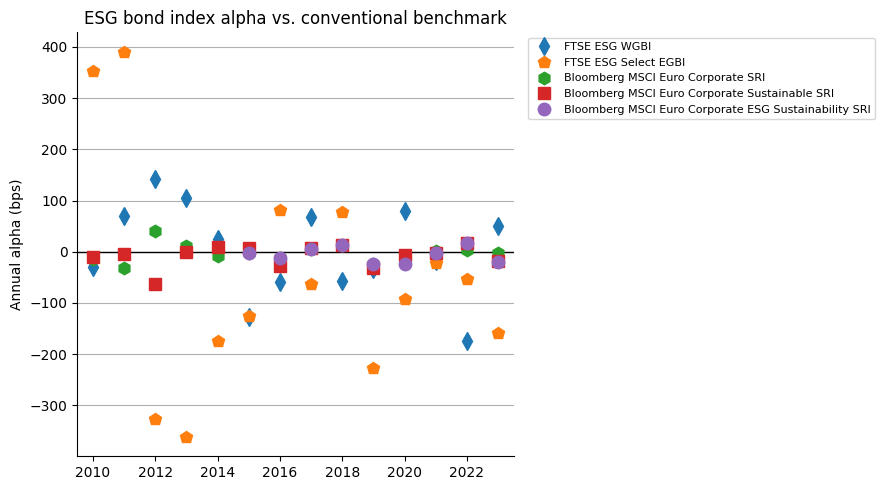

In [2]:

bond_idx = pd.read_excel(f"{DATA_DIR}/chap3_performance_bond_indices_2023.xlsx", sheet_name="alpha")
bond_idx = bond_idx.rename(columns={bond_idx.columns[0]: "Year"}).dropna(subset=["Year"])
year = bond_idx["Year"].values
alpha_cols = list(bond_idx.columns[1:])

fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(0, color="black", linewidth=1)
markers = ["d", "p", "h", "s", "o", "v"]
colors = plt.cm.tab10.colors
for i, col in enumerate(alpha_cols):
    y = bond_idx[col].values
    ax.plot(year, y, markers[i % len(markers)], color=colors[i % len(colors)],
            markersize=9, label=col)

ax.set_xlim(2009.5, 2023.5)
ax.set_xticks(np.arange(2010, 2024, 2))
ax.set_ylabel("Annual alpha (bps)")
ax.set_title("ESG bond index alpha vs. conventional benchmark")
ax.grid(axis="y")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()


### 1.2 ESG score distribution by credit quality

ESG-score distribution across all bonds, investment-grade (IG) and
high-yield (HY) subsets, read from the `ALL`/`IG`/`HY` sheets of
`chap3_performance_bond1.xlsx`. Each subset's density is compared
against a standard normal.

The "All" curve is a Gaussian fit to `score_ALL`'s own mean/std (not
a raw density estimate); "IG" is shifted by $+0.05$ with its kernel
bandwidth widened by $1.5\times$; "HY" uses a default-bandwidth
kernel density via `scipy.stats.gaussian_kde` (Scott's rule).

,mean,std
ALL,-0.13,1.01
IG,0.02,1.01
HY,-0.38,0.96


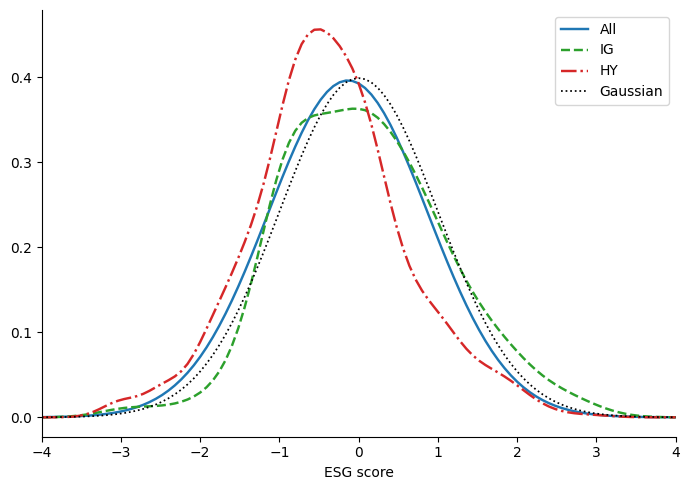

In [3]:

bond1_sheets = {s: pd.read_excel(f"{DATA_DIR}/chap3_performance_bond1.xlsx", sheet_name=s) for s in ["ALL", "IG", "HY"]}
score_all = bond1_sheets["ALL"]["Score"].dropna().astype(float).values
score_ig = bond1_sheets["IG"]["Score"].dropna().astype(float).values
score_hy = bond1_sheets["HY"]["Score"].dropna().astype(float).values

summary = pd.DataFrame(
    {"mean": [score_all.mean(), score_ig.mean(), score_hy.mean()],
     "std": [score_all.std(), score_ig.std(), score_hy.std()]},
    index=["ALL", "IG", "HY"],
)
display(summary.round(2))

x = np.linspace(-4, 4, 101)
y_all_fit = stats.norm.pdf(x, score_all.mean(), score_all.std())

kde_ig = stats.gaussian_kde(score_ig + 0.05)
kde_ig.set_bandwidth(kde_ig.factor * 1.5)
y_ig = kde_ig(x)

y_hy = stats.gaussian_kde(score_hy)(x)
y_std_normal = stats.norm.pdf(x, 0, 1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x, y_all_fit, "-", color="tab:blue", linewidth=1.75, label="All")
ax.plot(x, y_ig, "--", color="tab:green", linewidth=1.75, label="IG")
ax.plot(x, y_hy, "-.", color="tab:red", linewidth=1.75, label="HY")
ax.plot(x, y_std_normal, ":", color="black", linewidth=1.25, label="Gaussian")
ax.set_xlabel("ESG score")
ax.set_xlim(-4, 4)
ax.legend()
plt.tight_layout()
plt.show()


### 1.3 Credit spread by ESG-sorted quintile

Average credit spread (bps) of the best (Q5) to worst (Q1) ESG-score
quintile portfolios, two sub-periods, with a quadratic fit through the
five points (`numpy.polyfit`, degree 2) to show the shape of the
relationship.

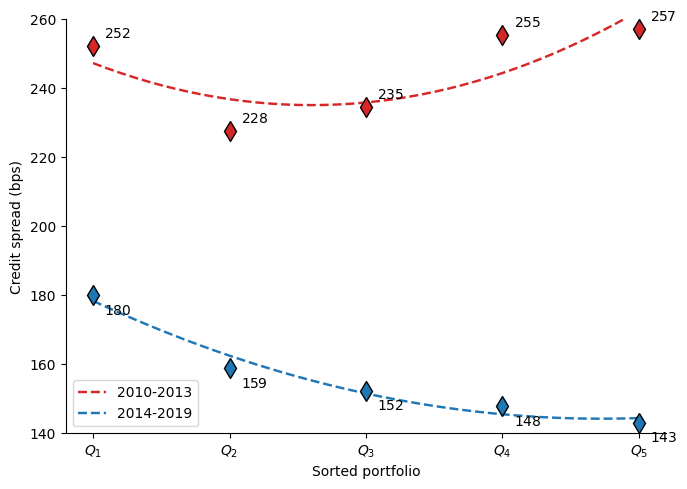

In [4]:

data = np.array([
    [252.2, 180.0],
    [227.5, 159.0],
    [234.7, 152.4],
    [255.4, 147.9],
    [257.2, 143.1],
])
q = np.arange(1, 6)
s = np.linspace(1, 5, 41)
periods = ["2010-2013", "2014-2019"]
colors = ["tab:red", "tab:blue"]

fig, ax = plt.subplots(figsize=(7, 5))
for j in range(2):
    fit = np.polyval(np.polyfit(q, data[:, j], 2), s)
    ax.plot(s, fit, "--", color=colors[j], linewidth=1.75, label=periods[j])
    ax.plot(q, data[:, j], "d", color=colors[j], markeredgecolor="k", markersize=10)
    for qi, v in zip(q, data[:, j]):
        ax.annotate(f"${v:.0f}$", (qi, v), textcoords="offset points",
                     xytext=(8, 6 if j == 0 else -14), fontsize=10)

ax.set_xticks(q)
ax.set_xticklabels([f"$Q_{i}$" for i in range(1, 6)])
ax.set_xlabel("Sorted portfolio")
ax.set_ylabel("Credit spread (bps)")
ax.set_ylim(140, 260)
ax.legend()
plt.tight_layout()
plt.show()


### 1.4 ESG/E/S/G excess return by currency and return type

Best-minus-worst-quintile excess return (bps) for the composite ESG
score and each of its E/S/G components, across four EUR/USD
total-return/excess-return variants, compared between two
sub-periods.

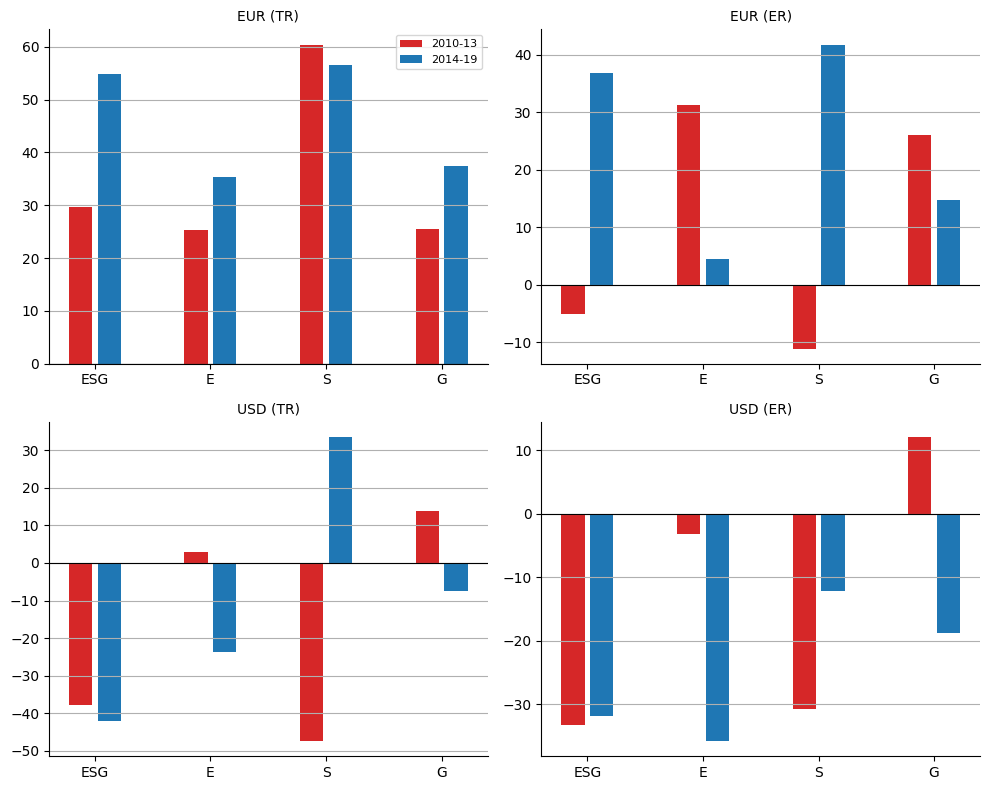

In [5]:

bond3_data = {
    "EUR (TR)": np.array([[29.7, 25.4, 60.3, 25.6], [54.8, 35.3, 56.5, 37.5]]),
    "EUR (ER)": np.array([[-5.0, 31.2, -11.1, 26.1], [36.9, 4.4, 41.8, 14.7]]),
    "USD (TR)": np.array([[-37.8, 2.8, -47.4, 13.8], [-42.0, -23.8, 33.5, -7.5]]),
    "USD (ER)": np.array([[-33.2, -3.1, -30.8, 12.1], [-31.8, -35.8, -12.1, -18.7]]),
}
labels = ["ESG", "E", "S", "G"]
s = np.arange(1, 5)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (title, data) in zip(axes.flat, bond3_data.items()):
    ax.bar(s - 0.125, data[0], width=0.20, color="tab:red", label="2010-13")
    ax.bar(s + 0.125, data[1], width=0.20, color="tab:blue", label="2014-19")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(s)
    ax.set_xticklabels(labels)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y")

axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()


### 1.5 Tracking error vs. excess ESG score, four bond universes

Active/tracking-error cost of tilting a bond portfolio towards higher
ESG (or E/S/G) scores, four different bond universes -- each shows
tracking error (bps) rising with the target excess score, decomposed
by ESG/E/S/G where available.

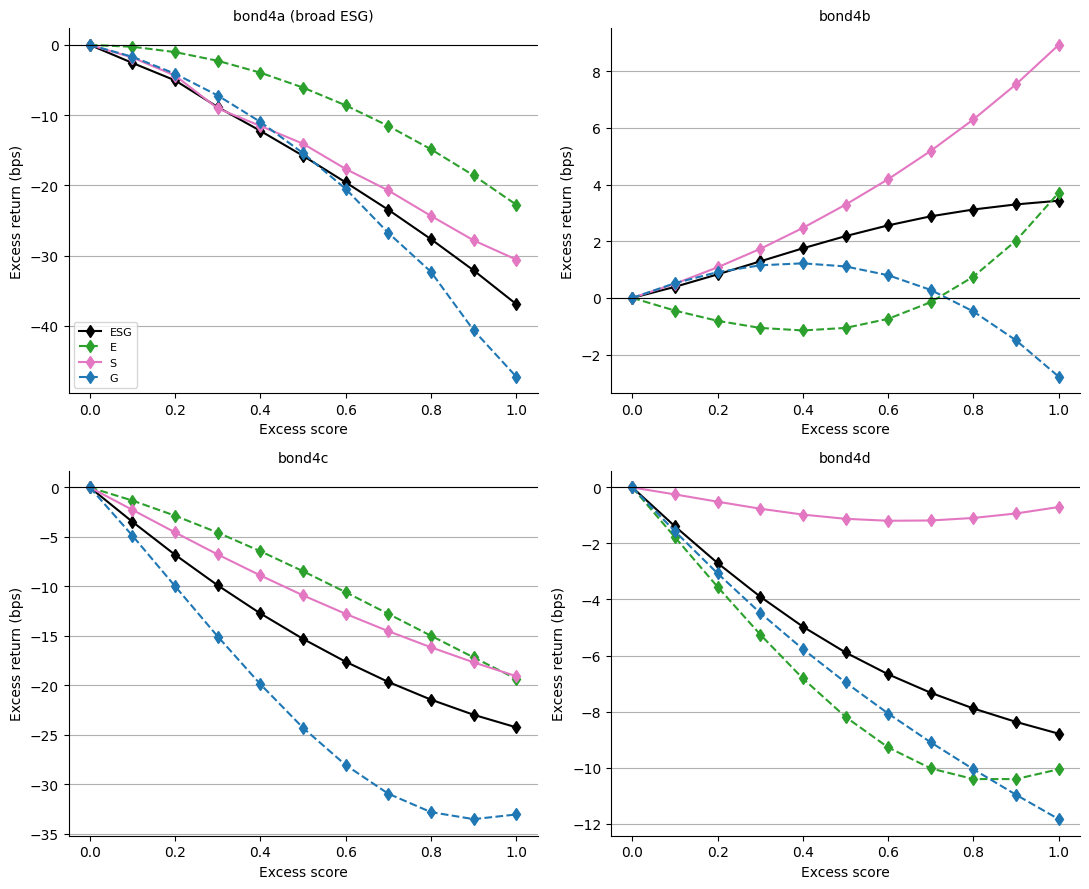

In [6]:

bond4 = {
    "bond4a (broad ESG)": {
        "score": np.linspace(0, 1.0, 11),
        "series": {"ESG": [0.00, -2.57, -5.05, -8.85, -12.23, -15.78, -19.56, -23.46, -27.64, -32.08, -36.88],
                   "E": [0.00, -0.26, -1.02, -2.26, -3.95, -6.07, -8.60, -11.53, -14.85, -18.57, -22.73],
                   "S": [0.00, -1.80, -4.36, -9.04, -11.53, -14.06, -17.65, -20.71, -24.33, -27.81, -30.55],
                   "G": [0.00, -1.69, -4.10, -7.20, -10.96, -15.40, -20.48, -26.75, -32.29, -40.60, -47.21]},
    },
    "bond4b": {
        "score": np.linspace(0, 1.0, 11),
        "series": {"ESG": [0.00, 0.39, 0.83, 1.29, 1.75, 2.18, 2.56, 2.88, 3.12, 3.30, 3.43],
                   "E": [0.00, -0.45, -0.81, -1.06, -1.15, -1.06, -0.74, -0.15, 0.75, 2.02, 3.71],
                   "S": [0.00, 0.50, 1.08, 1.73, 2.47, 3.29, 4.19, 5.19, 6.30, 7.54, 8.93],
                   "G": [0.00, 0.52, 0.91, 1.15, 1.22, 1.11, 0.80, 0.28, -0.48, -1.50, -2.78]},
    },
    "bond4c": {
        "score": np.linspace(0, 1.0, 11),
        "series": {"ESG": [0.00, -3.48, -6.81, -9.90, -12.74, -15.31, -17.62, -19.66, -21.45, -22.98, -24.25],
                   "E": [0.00, -1.33, -2.86, -4.57, -6.45, -8.47, -10.59, -12.78, -14.99, -17.18, -19.34],
                   "S": [0.00, -2.27, -4.55, -6.78, -8.90, -10.91, -12.78, -14.53, -16.16, -17.68, -19.08],
                   "G": [0.00, -4.88, -9.99, -15.07, -19.89, -24.30, -28.06, -30.96, -32.82, -33.53, -33.06]},
    },
    "bond4d": {
        "score": np.linspace(0, 1.0, 11),
        "series": {"ESG": [0.00, -1.39, -2.70, -3.90, -4.97, -5.89, -6.67, -7.33, -7.89, -8.37, -8.79],
                   "E": [0.00, -1.78, -3.55, -5.25, -6.82, -8.19, -9.28, -10.03, -10.41, -10.41, -10.06],
                   "S": [0.00, -0.25, -0.51, -0.76, -0.97, -1.12, -1.19, -1.18, -1.09, -0.93, -0.70],
                   "G": [0.00, -1.57, -3.07, -4.48, -5.77, -6.96, -8.07, -9.10, -10.06, -10.97, -11.84]},
    },
}
colors = {"ESG": "black", "E": "tab:green", "S": "tab:pink", "G": "tab:blue"}
styles = {"ESG": "-", "E": "--", "S": "-", "G": "--"}

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (title, d) in zip(axes.flat, bond4.items()):
    for key, y in d["series"].items():
        ax.plot(d["score"], y, "d" + styles[key], color=colors[key], markersize=6, label=key)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Excess score")
    ax.set_ylabel("Excess return (bps)")
    ax.grid(axis="y")

axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()


### 1.6 Excess return by credit rating

Best-minus-worst-ESG-quintile excess return (bps) within each
credit-rating bucket, CCC to AA.

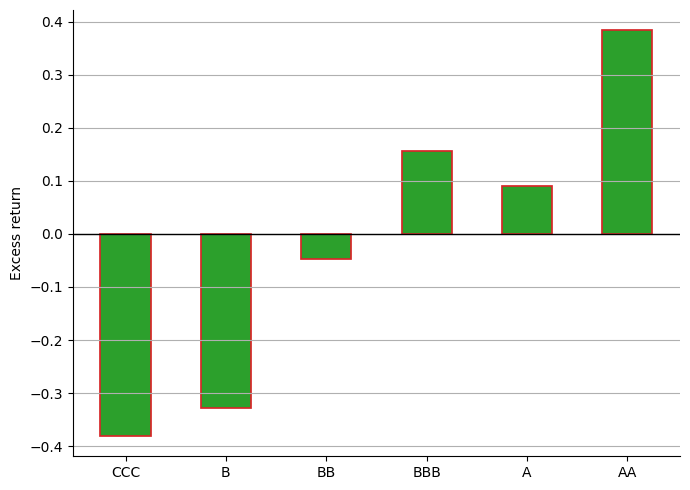

In [7]:

data = np.array([-0.381, -0.328, -0.048, 0.156, 0.090, 0.384])
labels = ["CCC", "B", "BB", "BBB", "A", "AA"]
s = np.arange(1, 7)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(s, data, width=0.5, edgecolor="tab:red", color="tab:green", linewidth=1.25)
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(s)
ax.set_xticklabels(labels)
ax.set_ylabel("Excess return")
ax.grid(axis="y")
plt.tight_layout()
plt.show()


## 2. Equity index ESG performance

Annual alpha (bps) of ten ESG equity indices (MSCI ESG Leaders/SRI
variants and S&P 500 ESG) against their conventional parent index,
read directly from the `Alpha` sheet of each vintage's workbook --
one using data through 2022, the other extended through 2023.

### 2.1 Equity index alpha, 2022 vintage

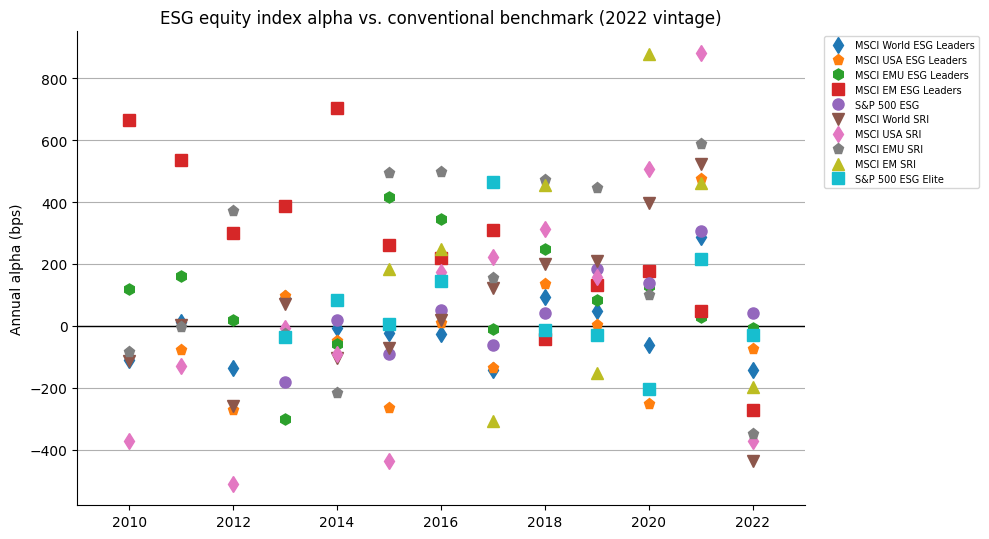

In [8]:

def plot_equity_alpha(xlsx_name, xlim, title):
    eq = pd.read_excel(f"{DATA_DIR}/{xlsx_name}", sheet_name="Alpha")
    eq = eq.rename(columns={eq.columns[0]: "Year"}).dropna(subset=["Year"])
    year = eq["Year"].values
    cols = list(eq.columns[1:])

    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.axhline(0, color="black", linewidth=1)
    markers = ["d", "p", "h", "s", "o", "v", "d", "p", "^", "s"]
    colors = plt.cm.tab10.colors
    for i, col in enumerate(cols):
        ax.plot(year, eq[col].values, markers[i % len(markers)],
                 color=colors[i % len(colors)], markersize=8, label=col)

    ax.set_xlim(*xlim)
    ax.set_ylabel("Annual alpha (bps)")
    ax.set_title(title)
    ax.grid(axis="y")
    ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1.0))
    plt.tight_layout()
    plt.show()


plot_equity_alpha("chap3_performance_equity_indices_2022.xlsx", (2009, 2023),
                   "ESG equity index alpha vs. conventional benchmark (2022 vintage)")


### 2.2 Equity index alpha, 2023 vintage

Same helper applied to the extended (2023) data vintage.

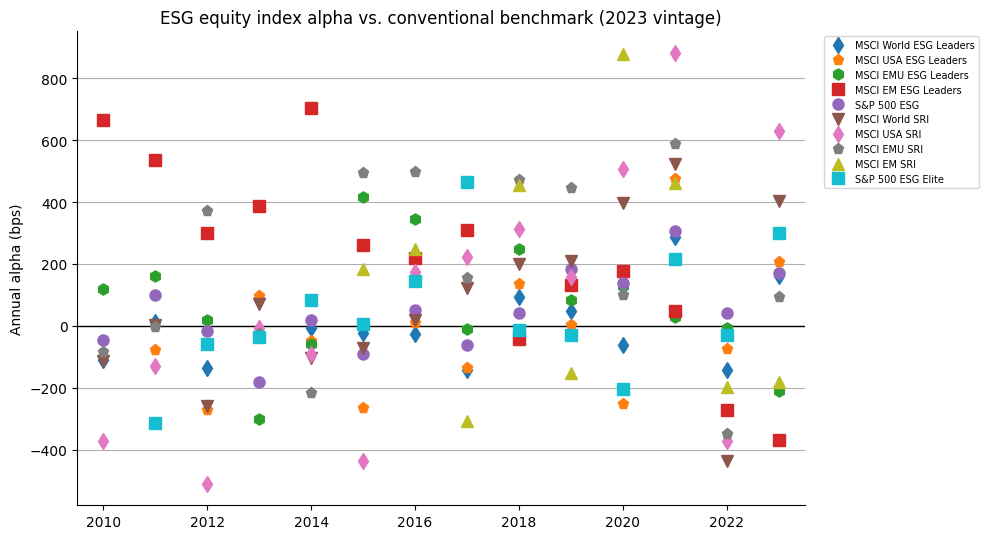

In [9]:

plot_equity_alpha("chap3_performance_equity_indices_2023.xlsx", (2009.5, 2023.5),
                   "ESG equity index alpha vs. conventional benchmark (2023 vintage)")


## 3. ESG as a LASSO-selected factor

A LASSO regularization path regresses returns on candidate style
factors (ESG, low-volatility, quality, value, momentum); as the L1
budget $\tau$ relaxes from 0 (no factors selected) to 1 (unconstrained
least squares), each factor's coefficient $\hat\beta$ enters the model
at its own pace. Two regional/period LASSO runs (weights $4.0$ and
$1.5$) are averaged via a cubic spline reinterpolated onto a common
$\tau$ grid.

In [10]:

def lasso_beta_paths(sheet1, sheet2, a=4.0, b=1.5):
    d1 = pd.read_excel(f"{DATA_DIR}/chap3_performance_lasso.xlsx", sheet_name=sheet1)
    d2 = pd.read_excel(f"{DATA_DIR}/chap3_performance_lasso.xlsx", sheet_name=sheet2)
    tau = np.linspace(0, 1, 200, endpoint=False)
    # Column position (not name): sheet-to-sheet naming is inconsistent
    # ("Low Vol" vs. "Low Volatility"), but the column order (ESG,
    # Low-vol, Quality, Value, Momentum) is the same in every sheet.
    factor_cols = ["ESG", "Low Vol", "Quality", "Value", "Momentum"]

    from scipy.interpolate import interp1d

    betas = []
    for i in range(len(factor_cols)):
        col_pos = 2 + i
        y1 = interp1d(d1["tau"], d1.iloc[:, col_pos], kind="cubic", fill_value="extrapolate")(tau)
        y2 = interp1d(d2["tau"], d2.iloc[:, col_pos], kind="cubic", fill_value="extrapolate")(tau)
        betas.append((a * y1 + b * y2) / (a + b))
    return tau, dict(zip(factor_cols, betas))


def plot_lasso_paths(tau, betas, title):
    fig, ax = plt.subplots(figsize=(7, 5.5))
    colors = {"Value": "tab:blue", "Momentum": "tab:red", "Low Vol": "tab:purple",
              "Quality": "tab:orange", "ESG": "tab:green"}
    styles = {"Value": "-", "Momentum": "--", "Low Vol": "-.", "Quality": "--", "ESG": "-"}
    for name, y in betas.items():
        ax.plot(100 * tau, 100 * np.clip(y, 0, None), styles[name], color=colors[name],
                 linewidth=1.75)
        ax.annotate(name, (100 * tau[-1], 100 * y[-1]), color=colors[name],
                     fontsize=11, fontweight="bold", xytext=(5, 0), textcoords="offset points")

    ax.axhline(0, color="black", linewidth=1)
    ax.set_xlabel("Factor intensity (%)")
    ax.set_ylabel(r"$\hat{\beta}$ (%)")
    ax.set_xlim(0, 120)
    ax.set_title(title)
    ax.grid(axis="y")
    plt.tight_layout()
    plt.show()


### 3.1 North America

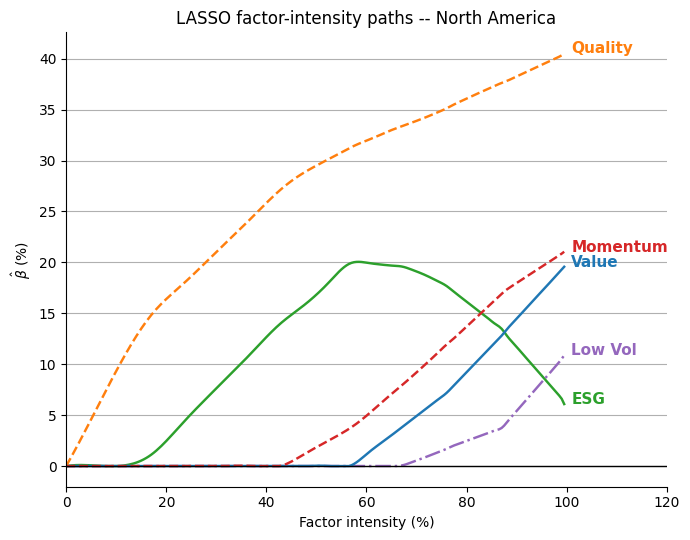

In [11]:

tau_na, betas_na = lasso_beta_paths("na1", "na2")
plot_lasso_paths(tau_na, betas_na, "LASSO factor-intensity paths -- North America")


### 3.2 Europe

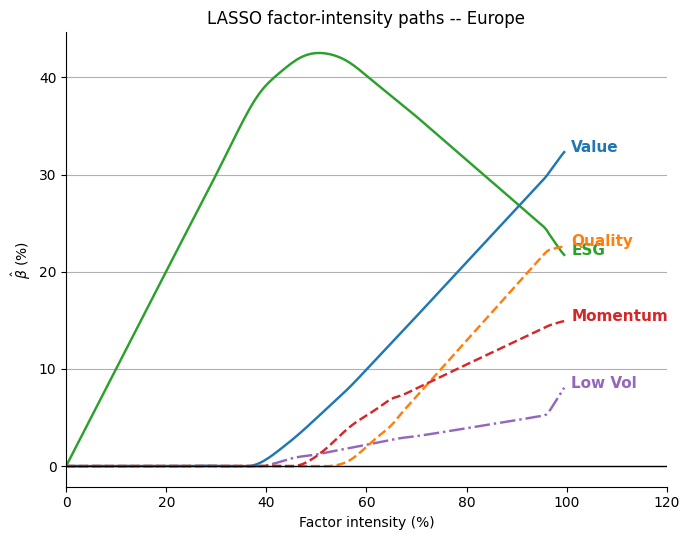

In [12]:

tau_eu, betas_eu = lasso_beta_paths("eu1", "eu2")
plot_lasso_paths(tau_eu, betas_eu, "LASSO factor-intensity paths -- Europe")


## 4. Optimized ESG-tilted portfolio performance

What happens once ESG tilting is done through an explicit
tracking-error-constrained optimization
(`quanttoolbox.portfolio.tracking_error.te_portfolio`, the same
function used in `03b` section 3) rather than a simple quintile sort:
how the optimal weights vary with score, the tracking-error cost of a
given score tilt, and the resulting excess returns across score
buckets, periods and regions.

### 4.1 Optimal weights vs. ESG score

A synthetic $n=500$-asset universe with i.i.d. returns whose
expected-return ranks match a standard-normal quantile transform of
the ESG score ($\mu_i = \Phi^{-1}(\text{rank}_i)$), $\sigma=20\%$
idiosyncratic risk, and an equal-weight benchmark. `te_portfolio` with
a small return tilt ($\gamma=0.001$) shows the optimizer tilting
weight monotonically with score, long-only ($0\le x_i\le 1$).

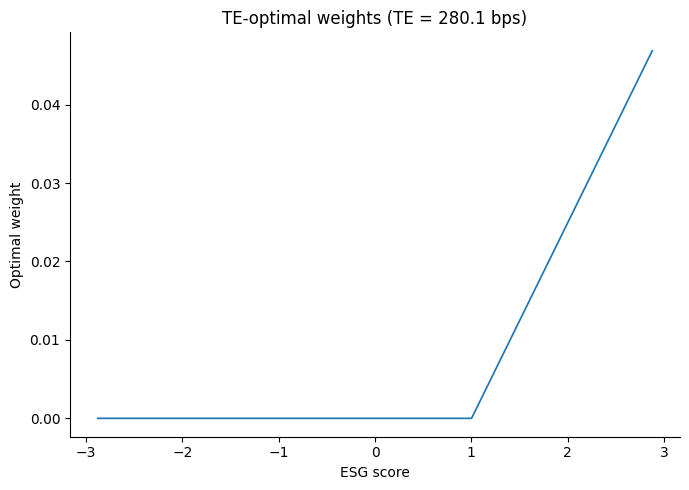

In [13]:

n = 500
alpha_grid = np.arange(1, n + 1) / (n + 1)
score = stats.norm.ppf(alpha_grid)
sigma = 0.20
Sigma = (sigma ** 2) * np.eye(n)
mu = score
benchmark = np.ones(n) / n

result = te_portfolio(benchmark, mu, Sigma, gamma=0.001, lb=0.0, ub=1.0)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(score, result.weights, color="tab:blue", linewidth=1.25)
ax.set_xlabel("ESG score")
ax.set_ylabel("Optimal weight")
ax.set_title(f"TE-optimal weights (TE = {10000 * result.tracking_error:.1f} bps)")
plt.tight_layout()
plt.show()


### 4.2 Tracking error vs. excess score

The tracking-error cost (bps) of achieving a given excess ESG score
for the optimized portfolio -- first for a single composite score
target, then decomposed into separate E/S/G tilts.

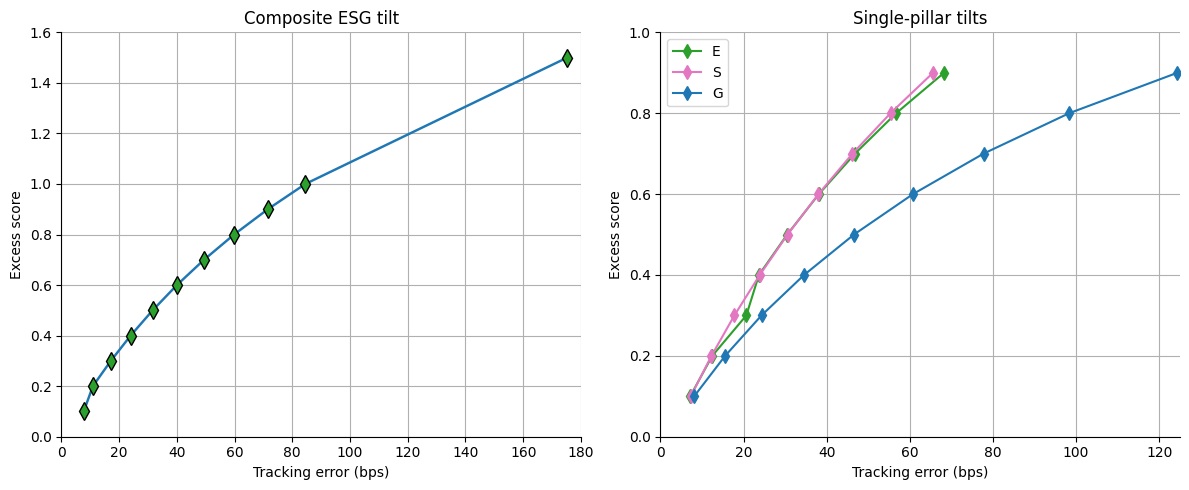

In [14]:

data_2a = np.array([
    [0.0773, 0.10], [0.1090, 0.20], [0.1711, 0.30], [0.2398, 0.40], [0.3160, 0.50],
    [0.4001, 0.60], [0.4939, 0.70], [0.5983, 0.80], [0.7150, 0.90], [0.8451, 1.00],
    [1.7523, 1.50],
])
te_2a, score_2a = 100 * data_2a[:, 0], data_2a[:, 1]

data_2b = np.array([
    [0.1, 0.0007155, 0.0007303, 0.0008112],
    [0.2, 0.0012460, 0.0012272, 0.0015558],
    [0.3, 0.0020661, 0.0017785, 0.0024313],
    [0.4, 0.0023687, 0.0023891, 0.0034550],
    [0.5, 0.0030492, 0.0030595, 0.0046564],
    [0.6, 0.0038123, 0.0038014, 0.0060758],
    [0.7, 0.0046801, 0.0046197, 0.0077726],
    [0.8, 0.0056711, 0.0055347, 0.0098341],
    [0.9, 0.0068229, 0.0065576, 0.0124368],
])
score_2b = data_2b[:, 0]
te_2b = 1e4 * data_2b[:, 1:]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(te_2a, score_2a, "-", color="tab:blue", linewidth=1.75)
axes[0].plot(te_2a, score_2a, "d", color="tab:green", markeredgecolor="k", markersize=9)
axes[0].set_xlabel("Tracking error (bps)")
axes[0].set_ylabel("Excess score")
axes[0].set_xlim(0, 180)
axes[0].set_ylim(0, 1.6)
axes[0].grid(True, which="both")
axes[0].set_title("Composite ESG tilt")

for j, (name, color) in enumerate(zip(["E", "S", "G"], ["tab:green", "tab:pink", "tab:blue"])):
    axes[1].plot(te_2b[:, j], score_2b, "d-", color=color, markersize=7, label=name)
axes[1].set_xlabel("Tracking error (bps)")
axes[1].set_ylabel("Excess score")
axes[1].set_xlim(0, 125)
axes[1].set_ylim(0, 1.0)
axes[1].grid(True)
axes[1].legend()
axes[1].set_title("Single-pillar tilts")

plt.tight_layout()
plt.show()


### 4.3 Excess return by score bucket, periods and pillars

Realized excess return (bps) of the optimized ESG-tilted portfolio
across excess-score buckets: first composite ESG across two periods,
then a per-pillar E/S/G breakdown for one period and another.

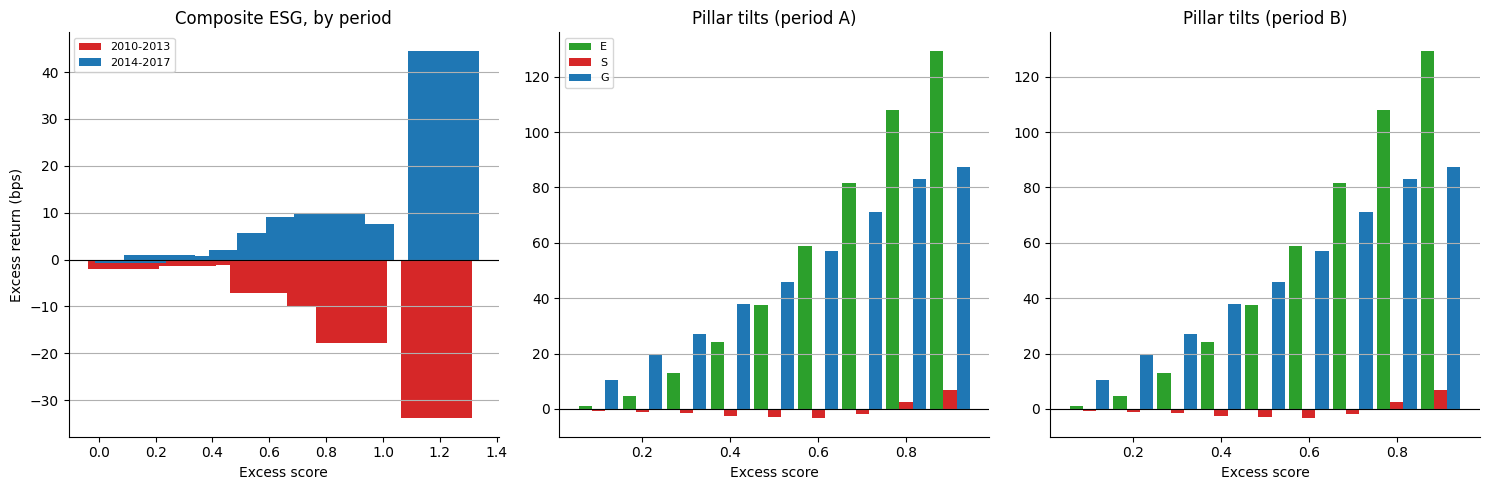

In [15]:

data_3a = np.array([
    [0.1, -0.0001927, -0.0000630], [0.2, -0.0000786, 0.0000905], [0.3, -0.0001328, 0.0000524],
    [0.4, -0.0001155, 0.0000854], [0.5, -0.0000642, 0.0002005], [0.6, -0.0007145, 0.0005731],
    [0.7, -0.0004944, 0.0008988], [0.8, -0.0010020, 0.0009990], [0.9, -0.0017852, 0.0007519],
    [1.2, -0.0033880, 0.0044560],
])
score_3a, er1_3a, er2_3a = data_3a[:, 0], 1e4 * data_3a[:, 1], 1e4 * data_3a[:, 2]

data_3b = np.array([
    [0.1, -0.0004133, 0.0001073, -0.0000864, 0.0010618],
    [0.2, 0.0005630, 0.0004709, -0.0000976, 0.0019669],
    [0.3, 0.0008527, 0.0013172, -0.0001552, 0.0026928],
    [0.4, 0.0011232, 0.0024182, -0.0002372, 0.0037882],
    [0.5, 0.0015665, 0.0037663, -0.0002953, 0.0045860],
    [0.6, 0.0024552, 0.0058701, -0.0003377, 0.0056942],
    [0.7, 0.0024934, 0.0081764, -0.0001983, 0.0071078],
    [0.8, 0.0032117, 0.0108050, 0.0002533, 0.0082931],
    [0.9, 0.0037799, 0.0129376, 0.0006782, 0.0087325],
])
data_3c = np.array([
    [0.1, -0.0004133, 0.0001073, -0.0000864, 0.0010618],
    [0.2, 0.0005630, 0.0004709, -0.0000976, 0.0019669],
    [0.3, 0.0008527, 0.0013172, -0.0001552, 0.0026928],
    [0.4, 0.0011232, 0.0024182, -0.0002372, 0.0037882],
    [0.5, 0.0015665, 0.0037663, -0.0002953, 0.0045860],
    [0.6, 0.0024552, 0.0058701, -0.0003377, 0.0056942],
    [0.7, 0.0024934, 0.0081764, -0.0001983, 0.0071078],
    [0.8, 0.0032117, 0.0108050, 0.0002533, 0.0082931],
    [0.9, 0.0037799, 0.0129376, 0.0006782, 0.0087325],
])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(score_3a - 0.0125, er1_3a, width=0.25, color="tab:red", label="2010-2013")
axes[0].bar(score_3a + 0.0125, er2_3a, width=0.25, color="tab:blue", label="2014-2017")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Excess score")
axes[0].set_ylabel("Excess return (bps)")
axes[0].set_title("Composite ESG, by period")
axes[0].legend(fontsize=8)
axes[0].grid(axis="y")

for ax, data, title in [(axes[1], data_3b, "Pillar tilts (period A)"),
                         (axes[2], data_3c, "Pillar tilts (period B)")]:
    s = data[:, 0]
    for j, (name, color) in enumerate(zip(["E", "S", "G"], ["tab:green", "tab:red", "tab:blue"])):
        ax.bar(s + (j - 1) * 0.03, 1e4 * data[:, j + 2], width=0.03, color=color, label=name)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Excess score")
    ax.set_title(title)
    ax.grid(axis="y")

axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


### 4.4 Excess return by region and period

The same ESG/E/S/G excess-return breakdown as above, now split by
region (North America, Europe) and sub-period (2010-2013, 2014-2017)
in a $2\times2$ grid.

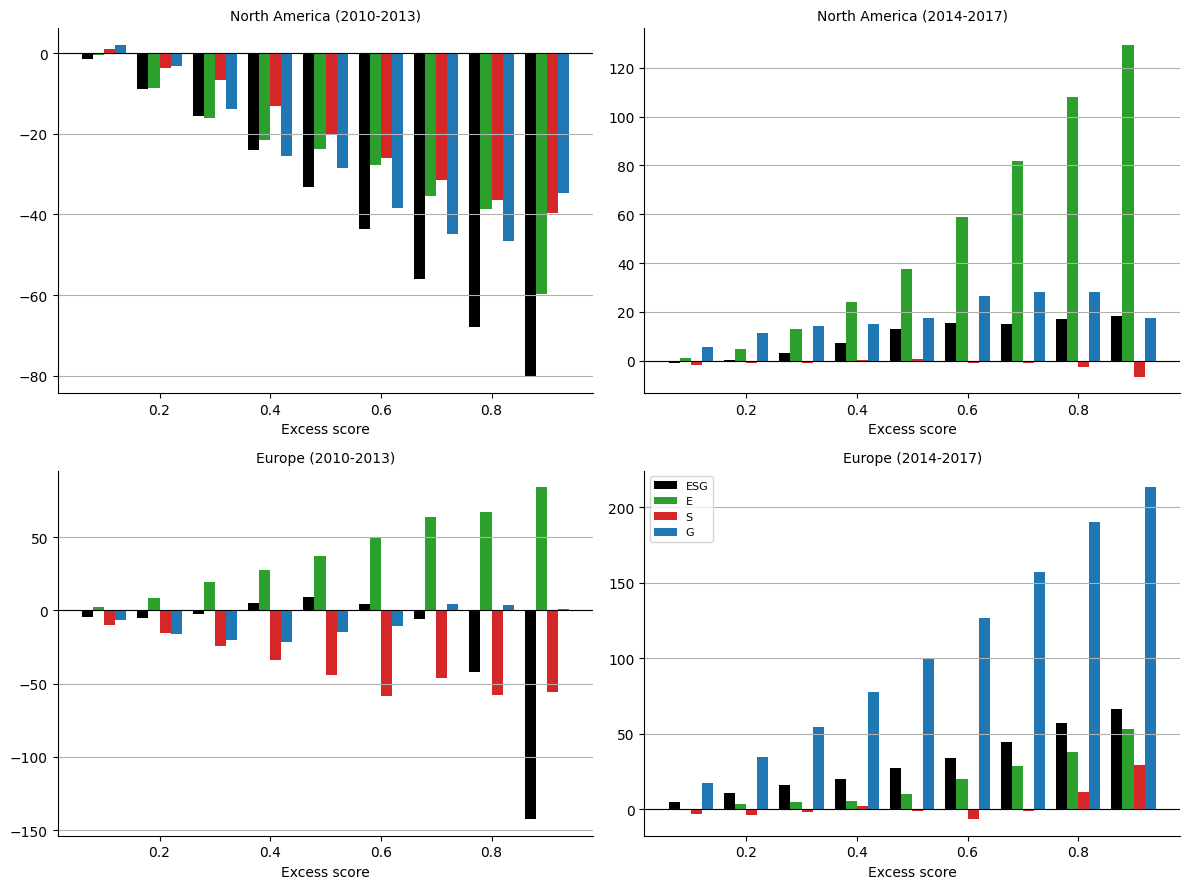

In [16]:

opt4_data = {
    "North America (2010-2013)": np.array([
        [0.1, -0.0001575, -0.0000519, 0.0001051, 0.0002008], [0.2, -0.0008846, -0.0008700, -0.0003699, -0.0003222],
        [0.3, -0.0015648, -0.0016044, -0.0006646, -0.0013750], [0.4, -0.0023961, -0.0021676, -0.0013132, -0.0025558],
        [0.5, -0.0033131, -0.0023678, -0.0020204, -0.0028553], [0.6, -0.0043510, -0.0027776, -0.0026019, -0.0038411],
        [0.7, -0.0056045, -0.0035352, -0.0031420, -0.0044772], [0.8, -0.0067846, -0.0038703, -0.0036424, -0.0046628],
        [0.9, -0.0080203, -0.0059619, -0.0039772, -0.0034722],
    ]),
    "North America (2014-2017)": np.array([
        [0.1, -0.0000780, 0.0001073, -0.0001638, 0.0005492], [0.2, 0.0000271, 0.0004709, -0.0001116, 0.0011391],
        [0.3, 0.0002998, 0.0013172, -0.0001041, 0.0014404], [0.4, 0.0007431, 0.0024182, 0.0000257, 0.0014912],
        [0.5, 0.0012854, 0.0037663, 0.0000810, 0.0017697], [0.6, 0.0015563, 0.0058701, -0.0001082, 0.0026591],
        [0.7, 0.0015148, 0.0081764, -0.0001049, 0.0028353], [0.8, 0.0017076, 0.0108050, -0.0002748, 0.0028106],
        [0.9, 0.0018354, 0.0129376, -0.0006501, 0.0017603],
    ]),
    "Europe (2010-2013)": np.array([
        [0.1, -0.000478, 0.000235, -0.000976, -0.000645], [0.2, -0.000558, 0.000853, -0.001551, -0.001642],
        [0.3, -0.000242, 0.001916, -0.002453, -0.002029], [0.4, 0.000504, 0.002741, -0.003398, -0.002162],
        [0.5, 0.000942, 0.003736, -0.004395, -0.001509], [0.6, 0.000410, 0.004913, -0.005812, -0.001094],
        [0.7, -0.000588, 0.006345, -0.004611, 0.000401], [0.8, -0.004182, 0.006689, -0.005750, 0.000360],
        [0.9, -0.014242, 0.008382, -0.005591, 0.000116],
    ]),
    "Europe (2014-2017)": np.array([
        [0.1, 0.00046383, 0.00004571, -0.00032502, 0.00172224], [0.2, 0.00106554, 0.00035332, -0.00035844, 0.00346635],
        [0.3, 0.00161158, 0.00046033, -0.00018979, 0.00545634], [0.4, 0.00203536, 0.00055942, 0.00024787, 0.00774260],
        [0.5, 0.00277272, 0.00101933, -0.00012039, 0.00997803], [0.6, 0.00342893, 0.00199248, -0.00064367, 0.01267536],
        [0.7, 0.00447159, 0.00284338, -0.00010285, 0.01569026], [0.8, 0.00571127, 0.00383248, 0.00115454, 0.01899742],
        [0.9, 0.00661559, 0.00529343, 0.00294587, 0.02131147],
    ]),
}
colors4 = {"ESG": "black", "E": "tab:green", "S": "tab:red", "G": "tab:blue"}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (title, data) in zip(axes.flat, opt4_data.items()):
    s = data[:, 0]
    for j, name in enumerate(["ESG", "E", "S", "G"]):
        ax.bar(s + (j - 1.5) * 0.02, 1e4 * data[:, j + 1], width=0.02, color=colors4[name], label=name)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Excess score")
    ax.grid(axis="y")

axes[1, 1].legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()


## 5. A taxonomy of score-performance patterns

A purely illustrative figure (no real data) sketching four archetypal
shapes a score-vs-performance relationship can take: monotonic in
return, monotonic in risk, a skewed-return relationship concentrated
at the tails, and a skewed-risk relationship. Random noise is
generated with a fixed `numpy` seed for a stable, reproducible figure;
the qualitative shapes are what this figure is meant to illustrate.

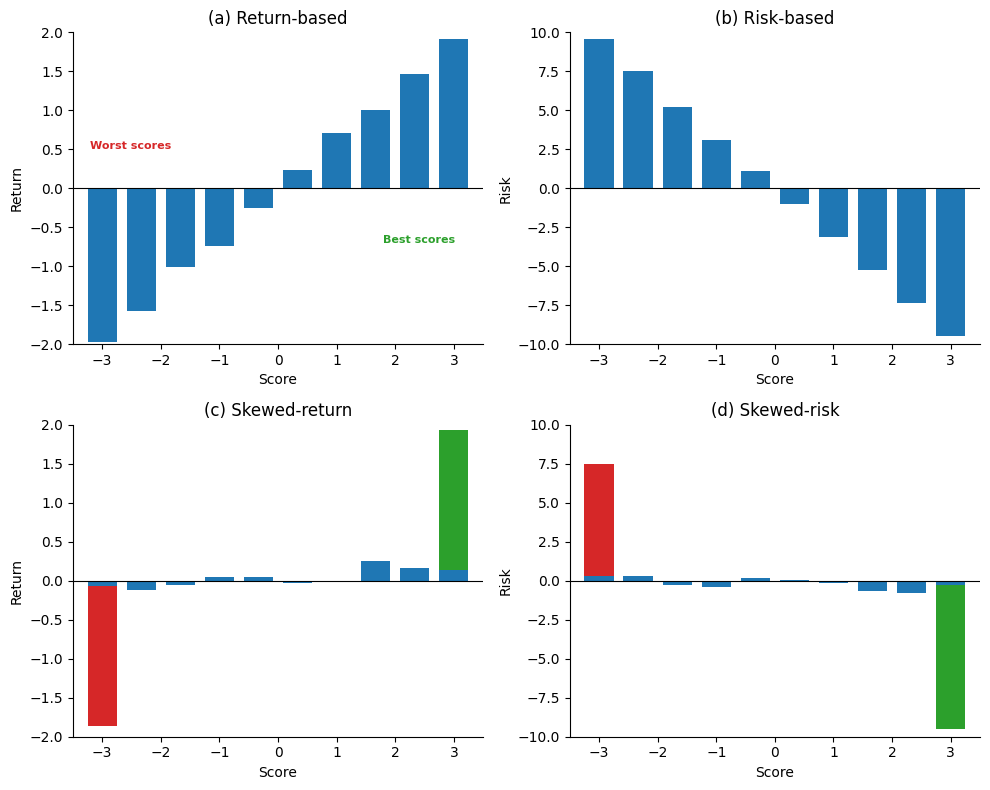

In [17]:

rng = np.random.default_rng(12367)
n = 10
x = np.linspace(-3, 3, n)

y1 = (np.linspace(-2.9, 2.9, n) + 0.1 * rng.standard_normal(n)) / 3 * 2
y2 = np.linspace(9.5, -9.5, n) + 0.1 * rng.standard_normal(n)

y3 = np.zeros((n, 3))
y3[:, 0] = 0.2 * rng.standard_normal(n)
y3[0, 0], y3[-1, 0] = -0.1, 0.2
y3[-1, 1] = 2.7
y3[0, 2] = -2.7
y3 = y3 / 3 * 2

y4 = np.zeros((n, 3))
y4[:, 0] = 0.5 * rng.standard_normal(n)
y4[0, 0], y4[-1, 0] = 0.3, -0.3
y4[-1, 1] = -9.2
y4[0, 2] = 7.2

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].bar(x, y1, width=0.5, color="tab:blue")
axes[0, 0].set(xlim=(-3.5, 3.5), ylim=(-2, 2), xlabel="Score", ylabel="Return", title="(a) Return-based")
axes[0, 0].text(1.8, -0.7, "Best scores", color="tab:green", fontweight="bold", fontsize=8)
axes[0, 0].text(-3.2, 0.5, "Worst scores", color="tab:red", fontweight="bold", fontsize=8)

axes[0, 1].bar(x, y2, width=0.5, color="tab:blue")
axes[0, 1].set(xlim=(-3.5, 3.5), ylim=(-10, 10), xlabel="Score", ylabel="Risk", title="(b) Risk-based")

axes[1, 0].bar(x, y3[:, 0], width=0.5, color="tab:blue")
axes[1, 0].bar(x, y3[:, 1], width=0.5, bottom=y3[:, 0], color="tab:green")
axes[1, 0].bar(x, y3[:, 2], width=0.5, bottom=y3[:, 0] + y3[:, 1], color="tab:red")
axes[1, 0].set(xlim=(-3.5, 3.5), ylim=(-2, 2), xlabel="Score", ylabel="Return", title="(c) Skewed-return")

axes[1, 1].bar(x, y4[:, 0], width=0.5, color="tab:blue")
axes[1, 1].bar(x, y4[:, 1], width=0.5, bottom=y4[:, 0], color="tab:green")
axes[1, 1].bar(x, y4[:, 2], width=0.5, bottom=y4[:, 0] + y4[:, 1], color="tab:red")
axes[1, 1].set(xlim=(-3.5, 3.5), ylim=(-10, 10), xlabel="Score", ylabel="Risk", title="(d) Skewed-risk")

for ax in axes.flat:
    ax.axhline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()


## 6. Sorted-portfolio (ESG-quintile) equity analysis

The simplest performance test in the toolkit -- sort stocks into
ESG-score quintiles ($Q_1$ = worst, $Q_5$ = best) and compare realized
returns -- applied to North American and European equities,
decomposed by E/S/G pillar and by sub-period. As in section 1.3, a
quadratic (or cubic, where appropriate) fit through the five quintile
points via `numpy.polyfit` traces the shape of the relationship.

### 6.1 Composite ESG quintile returns, North America & Europe

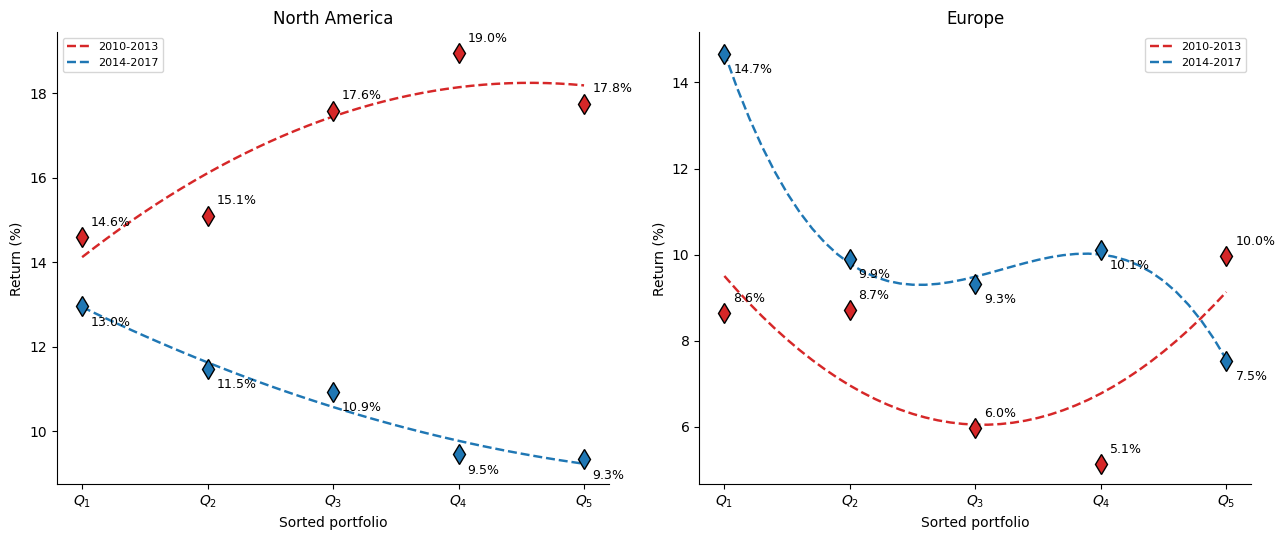

In [18]:

def quintile_fit_plot(ax, data, labels, degree=(2, 2), colors=("tab:red", "tab:blue"),
                       period_labels=("2010-2013", "2014-2017")):
    q = np.arange(1, 6)
    s = np.linspace(1, 5, 41)
    for j in range(2):
        fit = np.polyval(np.polyfit(q, data[:, j], degree[j]), s)
        ax.plot(s, fit, "--", color=colors[j], linewidth=1.75, label=period_labels[j])
        ax.plot(q, data[:, j], "d", color=colors[j], markeredgecolor="k", markersize=10)
        for qi, v in zip(q, data[:, j]):
            ax.annotate(f"${v:.1f}\\%$", (qi, v), textcoords="offset points",
                         xytext=(6, 8 if j == 0 else -14), fontsize=9)
    ax.set_xticks(q)
    ax.set_xticklabels([f"$Q_{i}$" for i in range(1, 6)])
    ax.set_xlabel("Sorted portfolio")
    ax.set_ylabel("Return (%)")
    ax.legend(fontsize=8)


data_sorted1 = np.array([[14.600, 12.960], [15.107, 11.479], [17.590, 10.936],
                          [18.953, 9.456], [17.754, 9.338]])
data_sorted2 = np.array([[8.647, 14.661], [8.704, 9.900], [5.968, 9.326],
                          [5.142, 10.113], [9.963, 7.538]])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
quintile_fit_plot(axes[0], data_sorted1, None, degree=(2, 2))
axes[0].set_title("North America")
quintile_fit_plot(axes[1], data_sorted2, None, degree=(2, 3))
axes[1].set_title("Europe")
plt.tight_layout()
plt.show()


### 6.2 E/S/G pillar quintile returns, North America & Europe

The same quintile-return-and-fit exercise, now run separately on each
of the three ESG pillars.

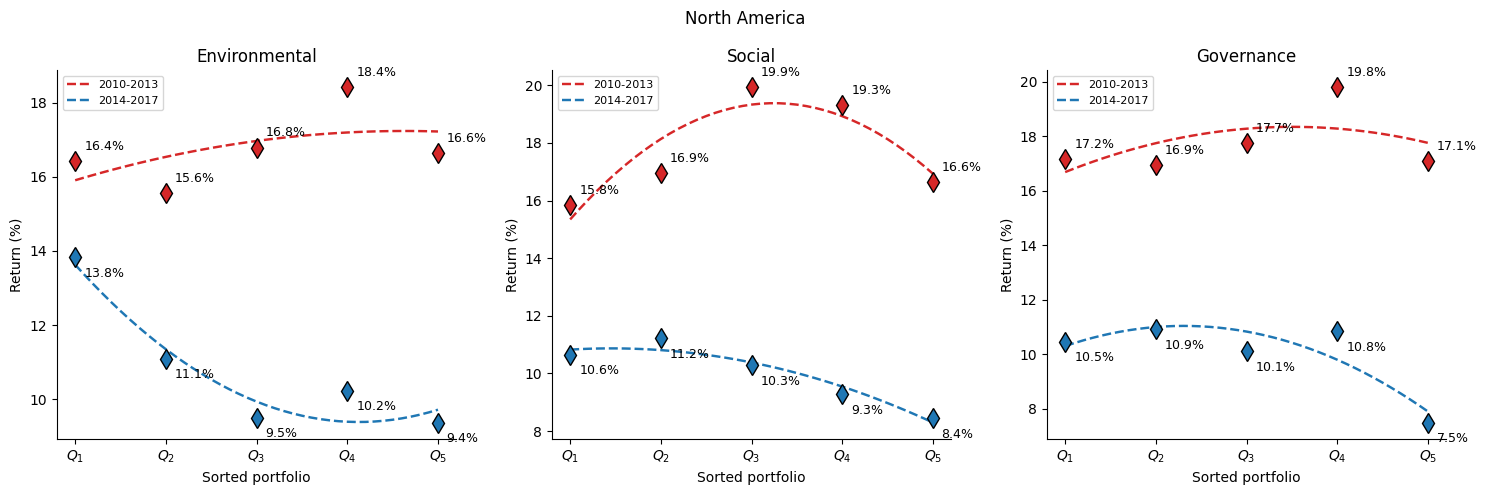

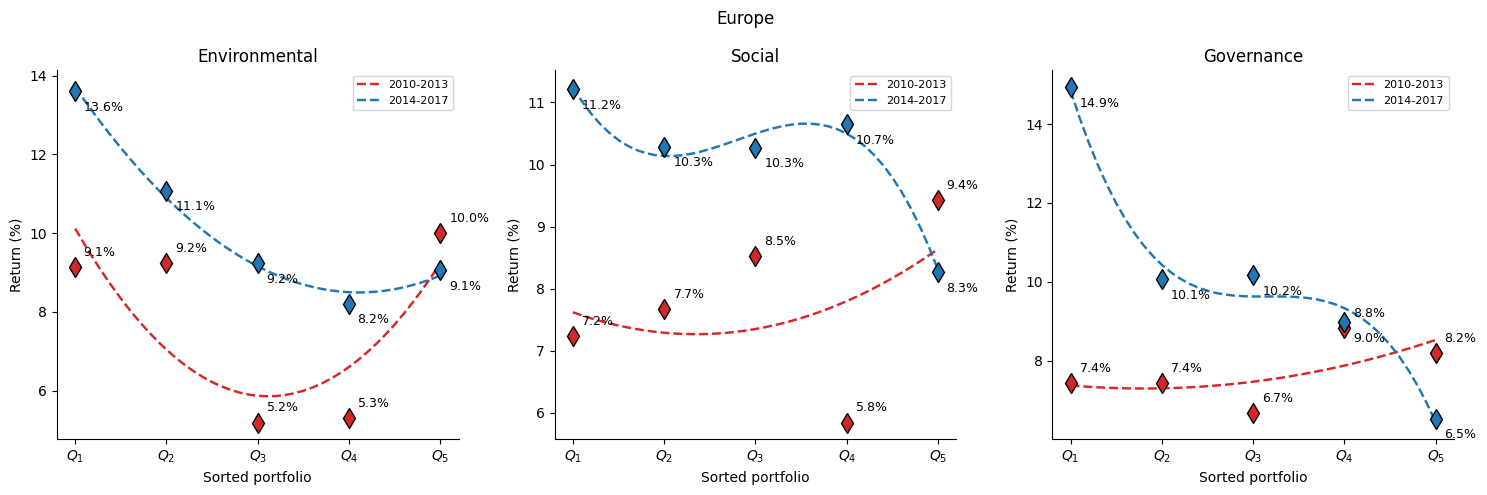

In [19]:

def pillar_quintile_grid(pillars, title):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (name, data, degree) in zip(axes, pillars):
        quintile_fit_plot(ax, data, None, degree=degree)
        ax.set_title(name)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


na_pillars = [
    ("Environmental", np.array([[16.43, 13.83], [15.55, 11.09], [16.79, 9.50], [18.42, 10.23], [16.64, 9.37]]), (2, 2)),
    ("Social", np.array([[15.84, 10.64], [16.95, 11.22], [19.94, 10.28], [19.31, 9.27], [16.64, 8.45]]), (2, 2)),
    ("Governance", np.array([[17.18, 10.46], [16.95, 10.92], [17.74, 10.10], [19.81, 10.85], [17.09, 7.49]]), (2, 2)),
]
pillar_quintile_grid(na_pillars, "North America")

eu_pillars = [
    ("Environmental", np.array([[9.13, 13.60], [9.24, 11.08], [5.19, 9.24], [5.31, 8.20], [10.00, 9.06]]), (2, 2)),
    ("Social", np.array([[7.23, 11.21], [7.67, 10.29], [8.53, 10.27], [5.84, 10.65], [9.42, 8.26]]), (2, 3)),
    ("Governance", np.array([[7.44, 14.94], [7.43, 10.07], [6.66, 10.17], [8.82, 8.97], [8.19, 6.52]]), (2, 3)),
]
pillar_quintile_grid(eu_pillars, "Europe")


### 6.3 ESG/E/S/G best-minus-worst-quintile alpha

The alpha of the best- vs. worst-ESG-quintile trade
(`(R_Q1 - R_Q5) / (1 + R_Q5)`, computed here from the same quintile
return data used above) for the composite score and each pillar,
three consecutive sub-periods.

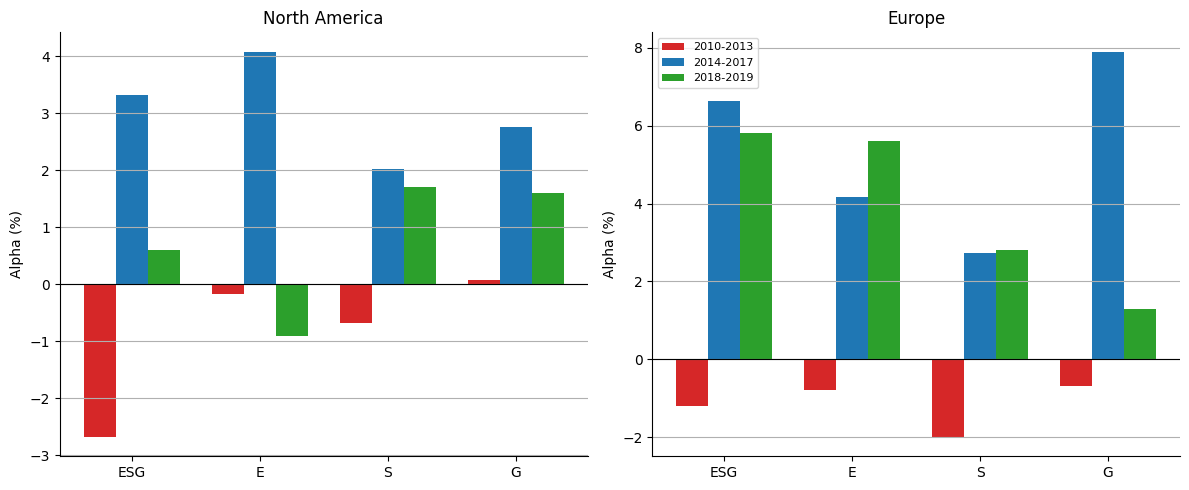

In [20]:

def q1_minus_q5_alpha(pillar_data, col3_hardcoded, floor=None):
    # pillar_data: 4 arrays [ESG, E, S, G], each shaped (5 quintiles, 2 periods)
    # -- the same arrays already used for the quintile-fit plots above.
    R_Q1 = np.array([d[0, :] for d in pillar_data]) / 100   # (4, 2): worst quintile
    R_Q5 = np.array([d[-1, :] for d in pillar_data]) / 100  # (4, 2): best quintile
    alpha_12 = 100 * (R_Q1 - R_Q5) / (1 + R_Q5)
    if floor is not None:
        alpha_12 = np.maximum(alpha_12, floor)
    return np.column_stack([alpha_12, col3_hardcoded])


na_pillar_data = [data_sorted1] + [p[1] for p in na_pillars]
alpha_na = q1_minus_q5_alpha(na_pillar_data, [0.6, -0.9, 1.7, 1.6])

eu_pillar_data = [data_sorted2] + [p[1] for p in eu_pillars]
alpha_eu = q1_minus_q5_alpha(eu_pillar_data, [5.8, 5.6, 2.8, 1.3], floor=-2.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ["ESG", "E", "S", "G"]
x = np.arange(1, 5)
period_labels = ["2010-2013", "2014-2017", "2018-2019"]
colors = ["tab:red", "tab:blue", "tab:green"]

for ax, alpha, title in [(axes[0], alpha_na, "North America"), (axes[1], alpha_eu, "Europe")]:
    for j in range(3):
        ax.bar(x + (j - 1) * 0.25, alpha[:, j], width=0.25, color=colors[j], label=period_labels[j])
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(title)
    ax.set_ylabel("Alpha (%)")
    ax.grid(axis="y")

axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()
